In [8]:
import sys
import os
import datetime
from copy import deepcopy
from multiprocessing.dummy import Pool
import random
import pickle

import numpy as np
import pandas as pd
from scipy.special import binom
import pandas as pd
import torch
from torch import nn
import cv2 as cv
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
plt.rc('font',family='Times New Roman')

__file__ = os.getcwd()
project_path = os.path.dirname(os.path.abspath(__file__))
sys.path.append(project_path)

from environment import rl_env, large_agents_planning_env

In [ ]:
file_path = project_path + '/results/30_30_dijkstra_path_with_marl_finished_time.pickle'
with open(file_path, 'rb') as file:
    ap = pickle.load(file)
    
length = 999

ap = ap[0]
ap.remove(np.max(ap))
ap = pd.DataFrame({'ap': ap})
ap[100] = ap.rolling(100, center=False).mean()
ap = ap[100]
av_p = np.mean(ap)
plt.plot(range(length), ap, 'r--', label='dijkstra path + MAPPO')
print(np.mean(ap))

file_path = project_path + '/results/30_30_dijkstra_path_finished_time.pickle'
with open(file_path, 'rb') as file:
    ap = pickle.load(file)

ap = ap[0]
ap.remove(np.max(ap))
ap = pd.DataFrame({'ap': ap})
ap[100] = ap.rolling(100, center=False).mean()
ap = ap[100]
av_d = np.mean(ap)
plt.plot(range(length), ap, 'g--', label='dijkstra path')
print(np.mean(ap))

plt.plot(range(length), [av_p] * length, 'b', label='average dijkstra path + MAPPO')
plt.plot(range(length), [av_d] * length, 'y', label='average dijkstra path')

# file_path = project_path + '/results/30_30_random_finished_time.pickle'
# with open(file_path, 'rb') as file:
#     ap = pickle.load(file)

# l3 = plt.plot(range(1000), ap[0], 'g', label='dijkstra path + random policy')

plt.xlabel('Episode')
plt.ylabel('Average time to complete 100 episodes')

plt.legend(loc = "best")
plt.title("30 * 30 Rectangular environment, 20 agents")
plt.savefig('30_env_20_agents.png', dpi=400)

In [ ]:
random.seed(400)
np.random.seed(400)

file_path = project_path + '/results/PPO_env10_agents10_block1_reward_type_default_planning.pickle'
k = np.random.randint(600, 4001, 8000).tolist()
with open(file_path, 'rb') as file:
    ap = pickle.load(file)[1] + k
ap = pd.DataFrame({'ap': ap})
ap[100] = ap.rolling(100, center=False).mean()

plt.plot(ap.index[: 7500], ap.loc[ap.index[: 7500], 100], 'y', label='PPO')

file_path = project_path + '/results/env10_agents10_block1_reward_type_default_planning.pickle'
with open(file_path, 'rb') as file:
    ap = pickle.load(file)[1]
ap = pd.DataFrame({'ap': ap})
ap[100] = ap.rolling(100, center=False).mean()

plt.plot(ap.index[: 7500], ap.loc[ap.index[: 7500], 100], 'g', label='MAPPO -1 reward')

plt.xlabel('Traing Episodes')
plt.ylabel('Average time to complete 100 episodes')

plt.legend(loc = "best")
plt.title("10 * 10 Rectangular environment, 10 agents")
plt.savefig('10_env_10_agents_PPO_convergence_line.png', dpi=400)

In [ ]:
file_path = project_path + '/results/PPO_env10_agents10_block1_reward_type_default_planning.pickle'
with open(file_path, 'rb') as file:
    ap = pickle.load(file)[1] + k
ap = pd.DataFrame({'ap': ap})
ap[100] = ap.rolling(100, center=False).mean()
ap

In [ ]:
file_path = project_path + '/results/random.pickle'
with open(file_path, 'rb') as file:
    ap = pickle.load(file)
ap = pd.DataFrame({'ap': ap})
ap[100] = ap.rolling(100, center=False).mean()
ap.min()

In [ ]:
ap.loc[ap[100] == ap[100].min()]

In [ ]:
file_path = project_path + '/results/env10_agents10_block1_reward_type_reverse_distance_planning.pickle'
with open(file_path, 'rb') as file:
    ap = pickle.load(file)[1]
ap = pd.DataFrame({'ap': ap})
ap[100] = ap.rolling(100, center=False).mean()

plt.plot(ap.index[: 7500], ap.loc[ap.index[: 7500], 100], 'r', label='reverse distance reward')

file_path = project_path + '/results/env10_agents10_block1_reward_type_default_planning.pickle'
with open(file_path, 'rb') as file:
    ap = pickle.load(file)[1]
ap = pd.DataFrame({'ap': ap})
ap[100] = ap.rolling(100, center=False).mean()

plt.plot(ap.index[: 7500], ap.loc[ap.index[: 7500], 100], 'g', label='default -1 reward')

file_path = project_path + '/results/random.pickle'
with open(file_path, 'rb') as file:
    ap = pickle.load(file)
ap = pd.DataFrame({'ap': ap})
ap[100] = ap.rolling(100, center=False).mean()

plt.plot(ap.index[: 7500], ap.loc[ap.index[: 7500], 100], 'b', label='random policy')

plt.xlabel('Traing Episodes')
plt.ylabel('Average time to complete 100 episodes')

plt.legend(loc = "best")
plt.title("10 * 10 Rectangular environment, 10 agents")
plt.savefig('10_env_10_agents_convergence_line.png', dpi=400)

In [ ]:
file_path = project_path + '/results/env10_agents10_block1_reward_type_reverse_distance_planning.pickle'
with open(file_path, 'rb') as file:
    ap = pickle.load(file)[1]
ap = pd.DataFrame({'ap': ap})
ap[100] = ap.rolling(100, center=False).mean()
plt.bar([0], ap[100].min(), color = "royalblue", width=4, label='reverse distance reward')

file_path = project_path + '/results/env10_agents10_block1_reward_type_default_planning.pickle'
with open(file_path, 'rb') as file:
    ap = pickle.load(file)[1]
ap = pd.DataFrame({'ap': ap})
ap[100] = ap.rolling(100, center=False).mean()
plt.bar([6], ap[100].min(), color = "darkorange", width=4, label='default -1 reward')

file_path = project_path + '/results/random.pickle'
with open(file_path, 'rb') as file:
    ap = pickle.load(file)
ap = pd.DataFrame({'ap': ap})
ap[100] = ap.rolling(100, center=False).mean()
plt.bar([12], ap[100].min(), color = "maroon", width=4, label='random policy')

plt.legend(loc = "best")
plt.ylabel("The shortest average time to complete 100 episodes")

plt.title("10 * 10 Rectangular environment, 10 agents")
plt.savefig('10_env_10_agents_histogram.png', dpi=400)

In [ ]:
env = rl_env(
    obstacles_index=([5], [5],),
    height=10,
    width=10,
    agents_num=10, 
)

In [ ]:
agents_p, target_p, blocks = env.reset()
target_p[np.where(target_p == 1)] = 3

In [ ]:
grid = target_p + blocks
grid[tuple(agents_p.reshape((-1, 2)).T.tolist())] = 2

In [2]:
COLORS = ['#FFFFFF', '#000000', '#FF0000', '#FFFF00']
CMAP = mcolors.LinearSegmentedColormap.from_list("", COLORS)
NORM = mcolors.Normalize(vmax=3, vmin=0)

In [3]:
with open(project_path + '/all_states.pickle', 'rb') as file:
    all_states = pickle.load(file)

In [4]:
states = all_states[2]
for i, obs in enumerate(states):
    agents_p, target_p, blocks = deepcopy(obs)
    target_p[np.where(target_p == 1)] = 3
    grid = target_p + blocks
    grid[tuple(agents_p[np.where(agents_p != -1)].reshape((-1, 2)).T.tolist())] = 2
    
    plt.imshow(grid, cmap=CMAP, norm=NORM, interpolation='none', extent=(0, 10, 10, 0))
    plt.xticks(range(10), labels=[])
    plt.yticks(range(10), labels=[])
    plt.grid(linewidth=1, color='black')
    # plt.show()
    plt.savefig('10_10_env_{}.png'.format(i), dpi=400)
    plt.close()

In [29]:
file_dir = project_path + '/jupyter_notebook/image/'

video=cv.VideoWriter(project_path + '/jupyter_notebook/test.MP4', cv.VideoWriter_fourcc(*'mp4v'), 20, (2400,1600))
for i in range(14 * 16):
    img=cv.imread(file_dir + '10_10_env_{}.png'.format(i // 16))
    video.write(img)

video.release()

In [5]:
all_states[0][0]

(array([[3, 9],
        [7, 2],
        [3, 2],
        [1, 1],
        [7, 3],
        [6, 3],
        [5, 9],
        [5, 2],
        [5, 4],
        [7, 1]]),
 array([[0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 0, 0, 1, 1, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 1, 0, 0, 0, 0]]),
 array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]))

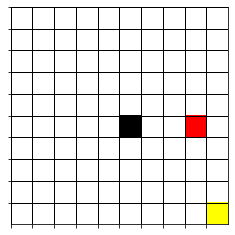

In [6]:
plt.imshow(grid, cmap=CMAP, norm=NORM, interpolation='none', extent=(0, 10, 10, 0))
plt.xticks(range(10), labels=[])
plt.yticks(range(10), labels=[])
plt.grid(linewidth=1, color='black')
plt.savefig('10_10_env.png', dpi=400)

In [ ]:
env = large_agents_planning_env()

In [ ]:
agents_p, target_p, blocks = env.reset()
target_p[np.where(target_p == 1)] = 3

In [ ]:
grid = target_p + blocks
grid[tuple(agents_p.reshape((-1, 2)).T.tolist())] = 2

In [ ]:
plt.imshow(grid, cmap=CMAP, norm=NORM, interpolation='none', extent=(0, 30, 30, 0))
plt.xticks(range(30), labels=[])
plt.yticks(range(30), labels=[])
plt.grid(linewidth=1, color='black')
plt.savefig('30_30_env.png', dpi=400)